In [2]:
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer


from sklearn.pipeline import FeatureUnion
from sklearn.decomposition import TruncatedSVD
from adjustText import adjust_text

from rital.data import (
    load_presidents,
    load_presidents_unseen,
)

from rital.movies.data import (
    load_movies,
    load_movies_unseen
)

from rital.preprocessing import (
    compute_odds_ratio,
    plot_frequencies,
    plot_word_cloud
)

from rital.presidents.preprocessing import (
    preprocess,
    tokenizer
)

from rital.presidents.analysis import (
    TextStats
)

from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords
PLOTS_DIR = "../plots/"

%load_ext autoreload
%autoreload 2

In [3]:
from imblearn.pipeline import Pipeline # supports for oversampling step
# from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
from sklearn.model_selection import (
    StratifiedKFold,
    KFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    train_test_split)
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    roc_curve, 
    roc_auc_score,
    f1_score)

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LogisticRegression  # TODO we can also use this
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.decomposition import TruncatedSVD

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

## Data Loading

In [33]:
PRESIDENTS = True

if PRESIDENTS:
    FILE_RADICAL = "pres-"
    X_train_full, y_train_full = load_presidents()
    X_test_unseen =load_presidents_unseen()
    label2name = {
    0 : "Chirac",
    1 : "Mitterrand"   
    }
    X_train_full_embeddings = np.load("X_train_full_embeddings.npy")
    STEMMER = SnowballStemmer("french")
    STOP_WORDS = stopwords.words("french")
else:
    FILE_RADICAL = "mov-"
    X_train_full, y_train_full = load_movies()
    X_train_full, y_train_full = np.array(X_train_full), np.array(y_train_full)
    X_test_unseen = np.array(load_movies_unseen())
    label2name = {
        0 : "negative",
        1 : "positive"
    }
    X_train_full_embeddings = None
    STEMMER = SnowballStemmer("english")
    STOP_WORDS = stopwords.words("english")



In [21]:
for label, name in label2name.items():
    print(f"({label}) {label2name[label]}: {np.sum(y_train_full == label)} texts")
print(f"Unseen test data: {len(X_test_unseen)} texts")

(0) negative: 1000 texts
(1) positive: 1000 texts
Unseen test data: 25000 texts


In [22]:
colors = ("#3C5488", "#E64B35")

Average text length 134.43977844738995
Average number of tokens 23.06660512427499


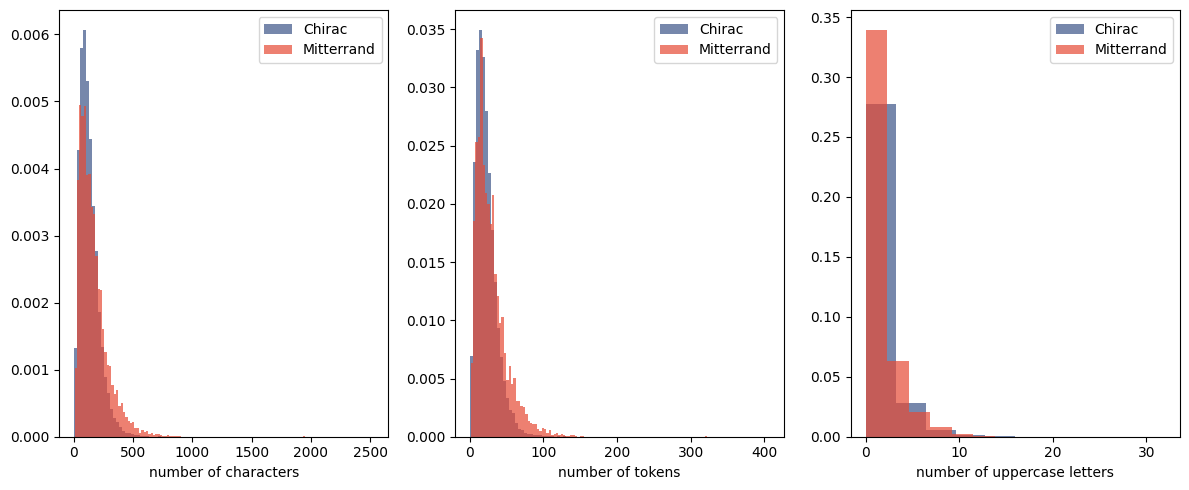

In [15]:
text_lengths = np.array([len(text) for text in X_train_full])
nb_tokens = np.array([len(preprocess(text).split()) for text in X_train_full])
nb_uppercase = np.array([sum(c.isupper() for c in text) for text in X_train_full])

print(f"Average text length {np.mean(text_lengths)}")
print(f"Average number of tokens {np.mean(nb_tokens)}")

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].hist(text_lengths[y_train_full == 0], alpha=0.7, label=label2name[0], bins=100, density=True, color = colors[0])
axes[0].hist(text_lengths[y_train_full == 1], alpha=0.7, label=label2name[1], bins=100, density=True, color = colors[1])
axes[0].set_xlabel("number of characters")
axes[0].legend()

axes[1].hist(nb_tokens[y_train_full == 0], alpha=0.7, label=label2name[0], bins=100, density=True, color = colors[0])
axes[1].hist(nb_tokens[y_train_full == 1], alpha=0.7, label=label2name[1], bins=100, density=True, color = colors[1])
axes[1].set_xlabel("number of tokens")
axes[1].legend()

axes[2].hist(nb_uppercase[y_train_full == 0], alpha=0.7, label=label2name[0], bins=10, density=True, color = colors[0])
axes[2].hist(nb_uppercase[y_train_full == 1], alpha=0.7, label=label2name[1], bins=10, density=True, color = colors[1])
axes[2].set_xlabel("number of uppercase letters")
axes[2].legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR + FILE_RADICAL + "text_stats.pdf")
plt.show()

/Users/vlad/Documents/University/Master-MIND/nlp-document-classification/.venv/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


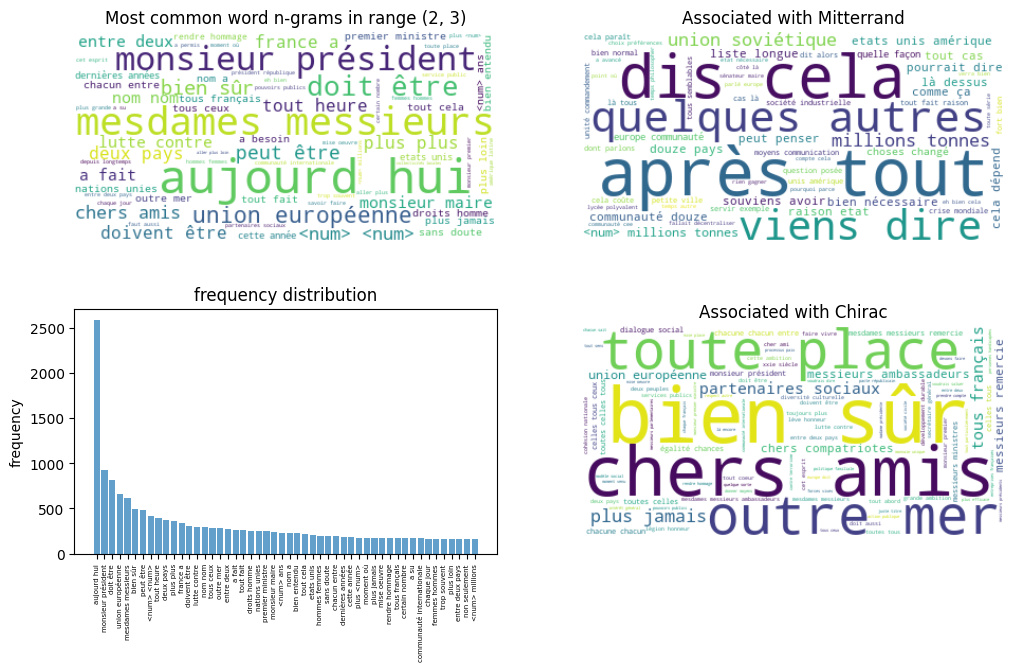

In [43]:
for analyzer in ["word"]:#, "char":
    for ngram_range in [(2,3)]:#, (2,2),(3,3), (4,4):
        vectorizer = TfidfVectorizer(preprocessor=partial(preprocess, lowercase=True, take_exceptions=False),
                                     analyzer=analyzer,
                                     lowercase=True,
                                    tokenizer=tokenizer,
                                    ngram_range=ngram_range,
                                    stop_words=STOP_WORDS,
                                    )
        count_vectorizer = CountVectorizer(preprocessor=partial(preprocess, lowercase=True, take_exceptions=False),
                                     analyzer=analyzer,
                                     lowercase=True,
                                    tokenizer=tokenizer,
                                    ngram_range=ngram_range,
                                    stop_words=STOP_WORDS,
                                    )
        
        fig, axes = plt.subplots(2,2, figsize=(12,7))
        axes = axes.flatten()
        
        X_train_tf_idf = vectorizer.fit_transform(X_train_full)
        vocab = vectorizer.get_feature_names_out()
        
        X_train_counts = count_vectorizer.fit_transform(X_train_full)
        vocab_counts= count_vectorizer.get_feature_names_out()
        plot_word_cloud(
            vocab, X_train_tf_idf.sum(0).A1,ax=axes[0], title=  f"Most common {analyzer}s ({len(vocab)} in total)" if ngram_range[1] == 1 else f"Most common {analyzer} n-grams in range {str(ngram_range)}"
        )
        plot_frequencies(vocab_counts, X_train_counts.sum(0).A1, top_k=50,ax=axes[2], title="frequency distribution")

        odds_ratio = compute_odds_ratio(X_train_tf_idf, y_train_full)

        plot_word_cloud(vocab, odds_ratio,ax=axes[1], title=f"Associated with {label2name[1]}")
        # plot_frequencies(vocab, odds_ratio, top_k=10, title=f"Words associated with {label2name[1]}")
        plot_word_cloud(vocab, 1 / odds_ratio,ax=axes[3], title=f"Associated with {label2name[0]}")
        # plot_frequencies(vocab, 1 / odds_ratio, top_k=10, title=f"Words associated with {label2name[0]}")
        # plt.tight_layout()
        plt.savefig(PLOTS_DIR + FILE_RADICAL + ((analyzer+"s"+"_stats.pdf") if ngram_range[1] == 1 else (analyzer + str(ngram_range) + "_stats.pdf")))
        plt.show()

# Dimension Reduction

In [18]:
feature_extractor = FeatureUnion([
            ("word_ngrams",TfidfVectorizer(
                analyzer="word",
                # preprocessor = partial(preprocess, stemmer = None),
                # tokenizer = tokenizer,
                # token_pattern = None,
                ngram_range=(1, 3),
                stop_words=STOP_WORDS,
                max_features=50_000,
                sublinear_tf = True,
                min_df=1,
                max_df=0.9
                
            )), # type: ignore
            
            ("char_ngrams", TfidfVectorizer(
                analyzer="char",
                ngram_range=(3, 6), # (2,5)
                max_features=50_000,
                lowercase=False,
                sublinear_tf = True,
                min_df=2,
                max_df=0.9,
            )), # type: ignore
            ("text_stats", Pipeline([
                ("stats", TextStats()),
                ("scaler", StandardScaler())
            ])) # type: ignore
            ]) 

In [19]:
X_features = {}
feature_names = {}
DATA_TYPES = ("word_ngrams", "char_ngrams", "text_stats")
for data_type in DATA_TYPES:
    X_features[data_type] = feature_extractor[data_type].fit_transform(X_train_full)
    feature_names[data_type] = feature_extractor[data_type].get_feature_names_out()

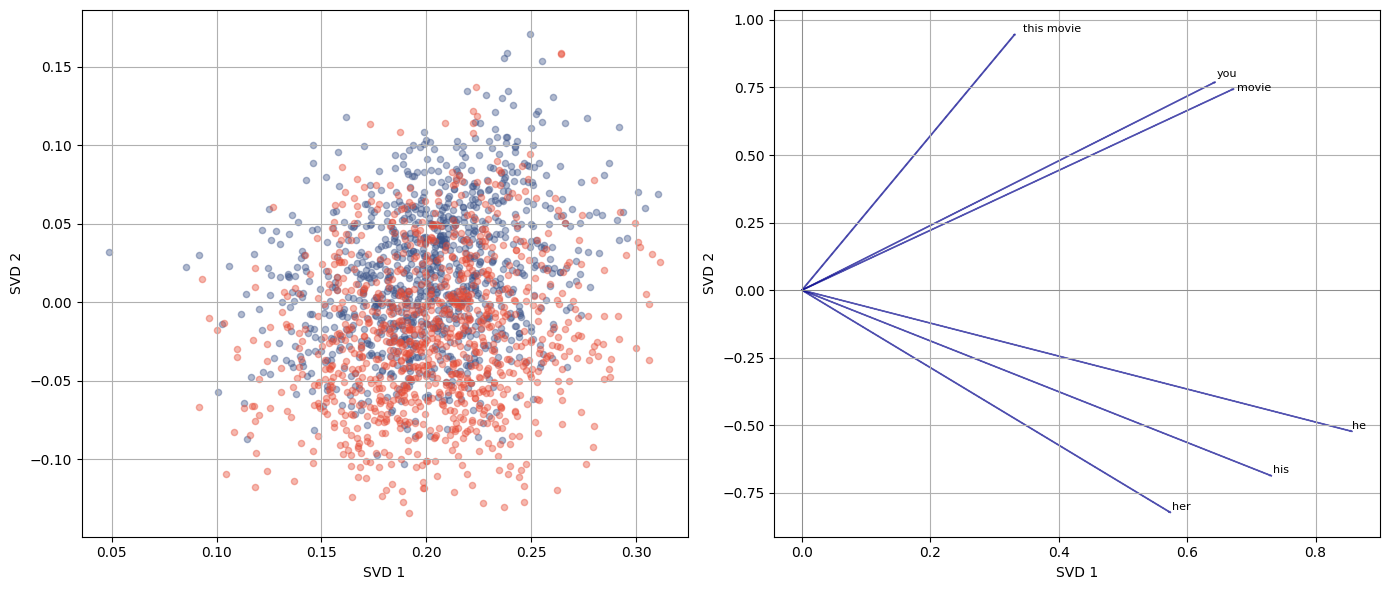

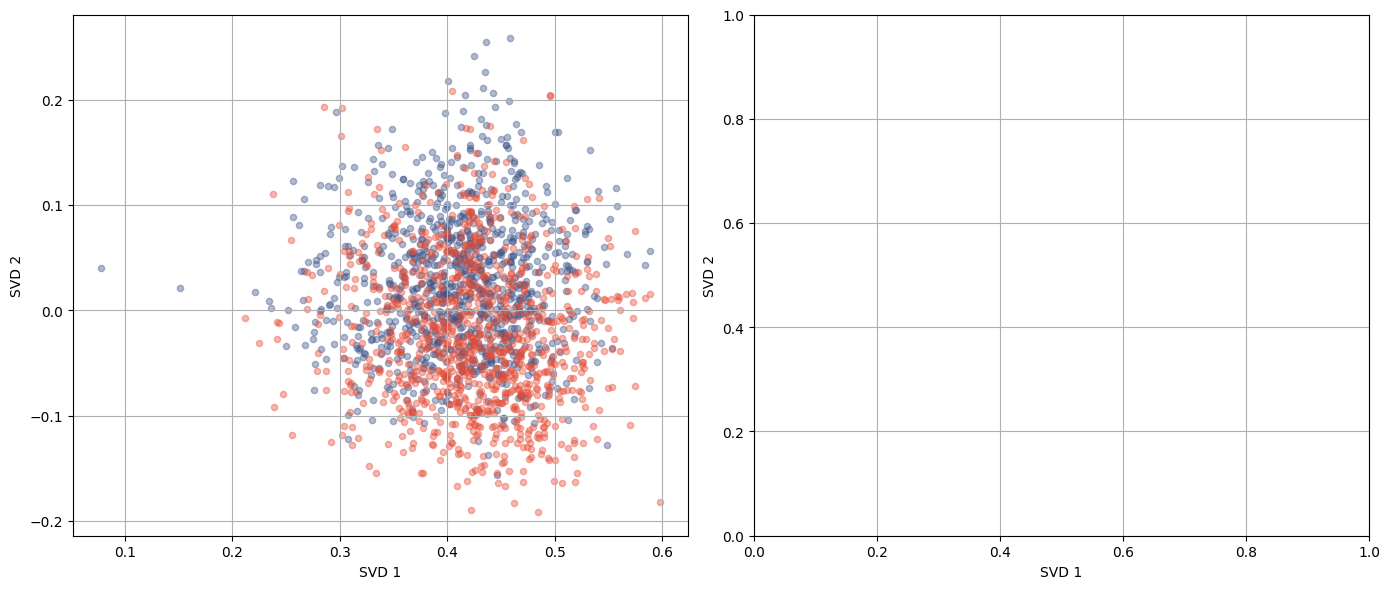

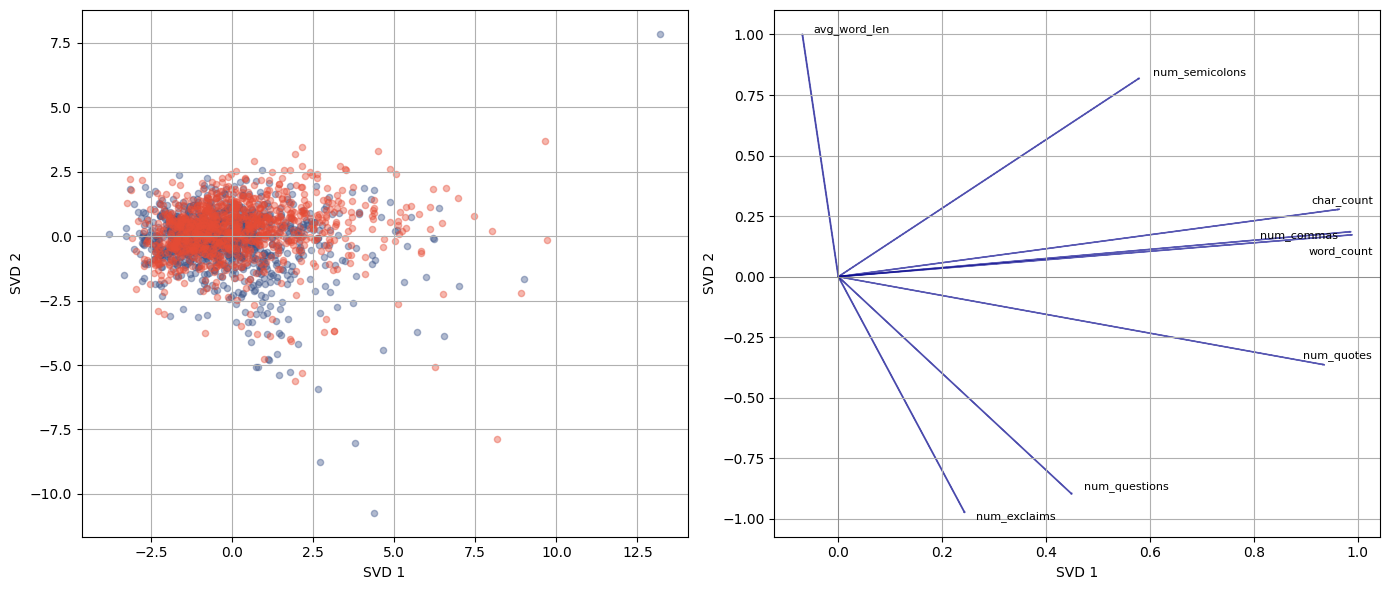

In [20]:
for data_type in DATA_TYPES:
    svd = TruncatedSVD(n_components=10)
    X_svd = svd.fit_transform(X_features[data_type])   

    pcs = (0,1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Samples ===========
    ax = axes[0]
    # get unique classes
    classes = np.unique(y_train_full)

    # choose distinct colors (good defaults)
    colors = colors#["tab:blue", "tab:orange"]

    for cls, color in zip(classes, colors):
        mask = (y_train_full == cls)
        
        ax.scatter(
            X_svd[mask, pcs[0]],
            X_svd[mask, pcs[1]],
            label=f"Class {cls}",
            alpha=0.4,
            color=color,
            s=20
        )

    ax.set_xlabel(f"SVD {pcs[0]+1}")
    ax.set_ylabel(f"SVD {pcs[1]+1}")
    # ax.set_title("Samples projection")
    ax.grid()

    # Features ========
    ax = axes[1]

    components = svd.components_
    xs = components[pcs[0], :]
    ys = components[pcs[1], :]
    threshold = 0.01

    texts = []
    for i in range(len(feature_names[data_type])):
        if xs[i]**2 + ys[i]**2 > threshold:
            
            norm = np.sqrt(xs[i]**2 + ys[i]**2)
            
            xs[i] = xs[i] / norm 
            ys[i] = ys[i] / norm 
            ax.arrow(0, 0, xs[i], ys[i],
                    color='darkblue', alpha=0.6)
            
            txt = ax.text(xs[i], ys[i],
                     feature_names[data_type][i], fontsize=8)
            texts.append(txt)
    adjust_text(texts, ax)
    
    

    ax.set_xlabel(f"SVD {pcs[0]+1}")
    ax.set_ylabel(f"SVD {pcs[1]+1}")
    # ax.set_title("Feature loadings")
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.axvline(0, color='grey', linewidth=0.5)
    ax.grid()
    
    # fig.suptitle(f"LSA for {data_type}")
    plt.savefig(PLOTS_DIR + FILE_RADICAL + "lsa_"+ data_type + ".pdf")

    plt.tight_layout()
    plt.show()

In [21]:
# from umap import UMAP

# umap = UMAP(n_neighbors=50, min_dist=0.1, metric='cosine')

# X_umap = {}
# for data_type in DATA_TYPES:
#     if data_type != "text_stats":
#         X_umap[data_type] = umap.fit_transform(X_features[data_type])

In [22]:
# for data_type, X in X_umap.items():
#     plt.scatter(X[:,0],X[:,1], c=y_train_full, alpha=0.1)
#     plt.xlabel("UMAP 1")
#     plt.ylabel("UMAP 2")
#     plt.title(data_type)
#     plt.show()

In [23]:
# # pip install install pyldavis
# from __future__ import print_function

# import pyLDAvis
# pyLDAvis.enable_notebook()

# from sklearn.decomposition import LatentDirichletAllocation


# from nltk.tokenize import RegexpTokenizer
# from sklearn.feature_extraction.text import CountVectorizer


# # Initialize regex tokenizer
# tokenizer = RegexpTokenizer(r'\w+')

# # Vectorize document using TF-IDF
# vectorizer = CountVectorizer(lowercase=True,
#                         stop_words=STOP_WORDS,
#                         ngram_range = (1,1),
#                         tokenizer = tokenizer.tokenize, max_df=0.95, min_df=2, max_features=1000)

# vectors = vectorizer.fit_transform(X_train_full)
# print(vectors.shape)
# print(vectors.nnz / float(vectors.shape[0]))

# lda = LatentDirichletAllocation(n_components=3)
# lda.fit(vectors)

# X = vectors 

# doc_topic_dists = lda.transform(X)

# topic_word_dists = lda.components_ / lda.components_.sum(axis=1)[:, np.newaxis]

# doc_lengths = X.sum(axis=1).A1

# vocab = vectorizer.get_feature_names_out()

# term_frequency = X.sum(axis=0).A1

# vis_data = pyLDAvis.prepare(
#     topic_word_dists,
#     doc_topic_dists,
#     doc_lengths,
#     vocab,
#     term_frequency
# )

# pyLDAvis.display(vis_data)